# Filtrado espacial<a class="tocSkip">
## TRATAMIENTO DE SEÑALES <a class="tocSkip">
### Ingenieria Electrónica <a class="tocSkip">
### Universidad Popular del Cesar <a class="tocSkip">
### Prof.: Jose Ramón Iglesias Gamarra - [https://github.com/joseramoniglesias/](https://github.com/joseramoniglesias/) <a class="tocSkip">
  **joseiglesias@unicesar.edu.co**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
import pylab
pylab.rcParams['figure.figsize'] = (3.0, 3.0)

Dimensiones de la imagen:  (512, 512)
Tipo de dato:  uint8
Nivel máximo de intensidad:  253
Nivel mínimo de intensidad:  0


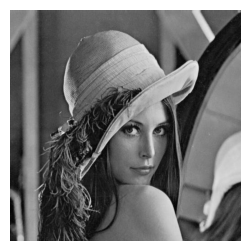

In [2]:
input_image=cv2.imread('lenna.jpg', cv2.IMREAD_GRAYSCALE)
img_max = np.max(input_image)
img_min = np.min(input_image)
ancho, alto = input_image.shape
print("Dimensiones de la imagen: ", input_image.shape)
print("Tipo de dato: ", input_image.dtype)
print("Nivel máximo de intensidad: ", img_max)
print("Nivel mínimo de intensidad: ", img_min)
plt.imshow(input_image, cmap='gray')
plt.axis('off')
plt.show()

## Convolución

Solución al ejercicio de realizar la convolución "manual" entre una imagen y un kernel:

In [3]:
def sum_of_products(kernel, img_region):
    '''
    Esta función recibe un filtro o kernel de tamaño arbitrario y la región de la imagen para realizar la operación de
    suma de productos, ambos elementos deben ser de la misma dimensión.

    Retorna el resultado de la operación en formato uint8.
    '''
    try:
        assert kernel.shape == img_region.shape # Verificación de que el tamaño del kernel y la región de la imagen coincidan
    except:
        print(f'Las dimensiones del kernel {kernel.shape} y de la región de la imagen {img_region.shape} no coinciden.')
    return np.sum(kernel*img_region).astype(np.uint8)

def zero_padding(img, pad_size):
    '''
    Esta función recibe una imagen y el tamaño del padding a cada lado (int).

    Retorna una nueva imagen con el contenido de la imagen original y padding cero en los bordes.
    '''
    # Dimensiones de la imagen original
    old_image_height, old_image_width = img.shape

    # Dimensiones de la imagen con padding
    new_image_width = old_image_width + 2*pad_size
    new_image_height = old_image_width + 2*pad_size

    pad_value = 0 # Valor de padding

    # Creación de la nueva imagen
    result = np.full((new_image_height, new_image_width), pad_value, dtype=np.uint8)

    x_ = (new_image_width - old_image_width) // 2 # Cálculo del desplazamiento de la imagen en el eje horizontal
    y_ = (new_image_height - old_image_height) // 2 # Cálculo del desplazamiento de la imagen en el eje vertical

    result[y_:y_+old_image_height,
        x_:x_+old_image_width] = img # Centrar la imagen original sobre la imagen con padding

    return result

def convolution(img, kernel, padding_func):
    '''
    Esta función recibe una imagen, un tamaño de kernel y la función de padding.
    Usa la funcion de suma de productos definida anteriormente.

    Retorna una nueva imagen resultado de aplicar la operación de convolución entre la imagen y el kernel.
    '''
    # Tamaño del padding a cada lado de la imagen
    pad_size = (kernel.shape[0]-1)//2

    # Llamada a la función de padding
    padded_img = padding_func(img, pad_size)

    # Dimensiones de la imagen
    height, width = img.shape

    # Creación de la matriz para la nueva imagen
    new_img = np.zeros((height, width), dtype=np.uint8)

    for i in range(height): # Iterar sobre las filas
        for j in range(width): # Iterar sobre las columnas
            current_i = pad_size + i # Empezar a recorrer la imagen en el primer píxel diferente de cero
            current_j = pad_size + j

            img_region = padded_img[current_i-pad_size:current_i+pad_size+1,
                                    current_j-pad_size:current_j+pad_size+1] # Ir seleccionando las regiones de la
                                                                             # imagen para aplicar la suma de productos
            # Llamada a la función de suma de productos
            new_img[i,j] = sum_of_products(kernel, img_region)
    return new_img

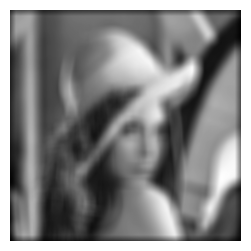

In [4]:
size = 27
smoothing = np.ones((size, size), dtype=np.float32) / (size**2)

imageOut = convolution(input_image, smoothing, zero_padding)
plt.imshow(imageOut, cmap='gray')
plt.axis('off')
plt.show()

Corrigiendo el error de los bordes oscuros con una forma diferente de realizar el padding conocida como padding espejo, en la que los valores de la imagen se reflejan alrededor de sus bordes.

In [5]:
def mirror_padding(img, pad_size):
    '''
    Esta función recibe una imagen y el tamaño del padding a cada lado (int).

    Retorna una nueva imagen con el contenido de la imagen original y padding simétrico en los bordes.
    '''
    return np.pad(img, pad_size, mode='symmetric')

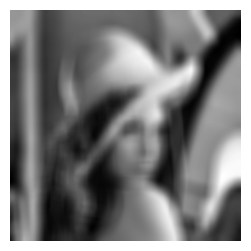

In [6]:
size = 31
smoothing = np.ones((size, size), dtype=np.float32) / (size**2)

imageOut = convolution(input_image, smoothing, mirror_padding)
plt.imshow(imageOut, cmap='gray')
plt.axis('off')
plt.show()

## El filtro gaussiano

Dada su simplicidad, los _Box filters_ o filtros de promedio son apropiados para experimentación rápida y usualmente obtienen buenos resultados de suavizado. Sin embargo hay algunas aplicaciones en las que no son la mejor opción para el procesamiento, por ejemplo cuando se quiere modelar o simular el efecto de un lente fuera de foco, o cuando la imagen que se quiere procesar tiene un alto nivel de detalle y objetos geométricos muy marcados, la direccionalidad de estos filtros genera comportamientos no deseados.

<img src="https://github.com/MoraRubio/dip-uam/blob/main/src/boxVgaussian.png?raw=true" alt="Comparación filtro de promedio y filtro gaussiano" style="height: 200px; width:700px;"/>

En estos casos se prefiere un filtro de simetría circular, o isotrópico, que actúa de la misma forma en todas las direcciones, uno de estos filtros son los de distribución gaussiana, en referencia a la campana de Gauss.

<img src="https://github.com/MoraRubio/dip-uam/blob/main/src/campanagauss.png?raw=true" alt="Campana gaussiana" style="height: 250px; width:400px;"/>

La cual está descrita por la siguiente fórmula matemática, donde $s$ y $t$ representan coordenadas espaciales:

$$G(s,t)=Ke^{-\frac{s^2+t^2}{2\sigma^2}}$$

Si muestreamos la función anterior para crear filtros discretos, obtenemos filtros de la siguiente forma:

<img src="https://github.com/MoraRubio/dip-uam/blob/main/src/filtrogaussiano.png?raw=true" alt="Kernel gaussiano" style="height: 500px; width:500px;"/>

<!--
def gaussian_filter(m, K, sigma):
    '''
    Esta función genera kernels gaussianos de tamaño arbitrario con la distribución determinada por los parámetros K y sigma.
    '''
    try:
        assert (m%2)!=0
    except:
        print('El tamaño del kernel debe ser impar')
        return None

    kernel = np.zeros((m,m), dtype=np.float64) # Arreglo que contendrá el filtro
    center = (m-1)//2 # Posición central del kernel
    for s in range(m):
        for t in range(m):
            s_ = np.abs(center-s) # Corección para ubicar el (0,0) en el centro del kernel
            t_ = np.abs(center-t)
            kernel[s,t] = K*np.exp(-(s_**2+t_**2)/(2*sigma**2)) # Cálculo de los valores
    return kernel/np.sum(kernel)
-->

In [9]:
def gaussian_filter(m, K, sigma):
    '''
    Esta función genera kernels gaussianos de tamaño arbitrario
    con la distribución determinada por los parámetros K y sigma.
    '''
    # Crear una cuadrícula de coordenadas centrada en el origen
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    gauss_1d = np.exp(-0.5 * (ax / std) ** 2)
    # Multiplicación externa para obtener la matriz 2D y aplicar la constante K
    kernel_2d = K * np.outer(gauss_1d, gauss_1d)
    # Opcional: Normalizar el kernel para que la iluminación de la imagen no cambie
    return kernel_2d / np.sum(kernel_2d)

gaussian_filter(3, 1.0, 1.0)

array([[0.00117306, 0.00128997, 0.00140441, 0.0015138 , 0.00161546,
        0.0017068 , 0.00178536, 0.00184895, 0.00189576, 0.00192441,
        0.00193406, 0.00192441, 0.00189576, 0.00184895, 0.00178536,
        0.0017068 , 0.00161546, 0.0015138 , 0.00140441, 0.00128997,
        0.00117306],
       [0.00128997, 0.00141853, 0.00154438, 0.00166466, 0.00177646,
        0.0018769 , 0.00196329, 0.00203322, 0.00208469, 0.0021162 ,
        0.0021268 , 0.0021162 , 0.00208469, 0.00203322, 0.00196329,
        0.0018769 , 0.00177646, 0.00166466, 0.00154438, 0.00141853,
        0.00128997],
       [0.00140441, 0.00154438, 0.00168139, 0.00181234, 0.00193406,
        0.00204341, 0.00213746, 0.0022136 , 0.00226964, 0.00230394,
        0.00231549, 0.00230394, 0.00226964, 0.0022136 , 0.00213746,
        0.00204341, 0.00193406, 0.00181234, 0.00168139, 0.00154438,
        0.00140441],
       [0.0015138 , 0.00166466, 0.00181234, 0.00195349, 0.00208469,
        0.00220256, 0.00230394, 0.002386  , 0.0024464

### Suavizado con filtro gaussiano

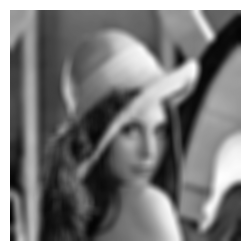

In [10]:
size = 21
K = 1.0
std = 10.0
gaussian = gaussian_filter(size, K, std)
imageOut = cv2.filter2D(input_image, -1, gaussian) # Aplicación del filtro
plt.imshow(imageOut, cmap='gray')
plt.axis('off')
plt.show()

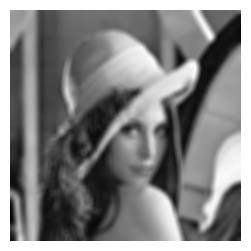

In [11]:
size = (15, 15)
std = 10.0
imageOut = cv2.GaussianBlur(input_image, size, std) # Aplicación del filtro
plt.imshow(imageOut, cmap='gray')
plt.axis('off')
plt.show()

### Reducción de ruido con filtro gaussiano

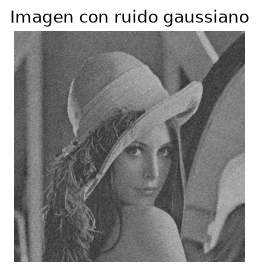

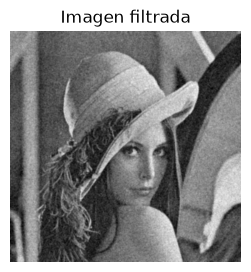

In [12]:
noise_factor = 30 # Factor de amplificación del ruido
noisy_image = input_image + noise_factor*np.random.randn(ancho, alto) # Añadir ruido gaussiano a la imagen
plt.imshow(noisy_image, cmap='gray')
plt.title('Imagen con ruido gaussiano')
plt.axis('off')
plt.show()

size = 21
K = 1.0
std = 1.0
gaussian = gaussian_filter(size, K, std)

imageOut = cv2.filter2D(noisy_image, -1, gaussian)
plt.imshow(imageOut, cmap='gray')
plt.title('Imagen filtrada')
plt.axis('off')
plt.show()

## Filtros no lineales

Los filtros no lineales son aquellos que realizan una operación no lineal sobre las regiones de la imagen. El más conocido es el filtro de mediana que reemplaza el valor del píxel central por la mediana de intensidad de los píxeles que hacen parte de la región.

<!--
def median_filter(img, kernel_size, padding_func):
    '''
    Esta función recibe una imagen, un tamaño de kernel y la función de padding.

    Retorna una nueva imagen resultado de aplicar el filtro de mediana.
    '''
    try:
        assert (kernel_size%2)!=0
    except:
        print('El tamaño del kernel debe ser impar')
        return None

    # Tamaño del padding a cada lado de la imagen
    pad_size = (kernel_size-1)//2

    # Llamada a la función de padding
    padded_img = padding_func(img, pad_size)

    # Dimensiones de la imagen
    height, width = img.shape

    # Creación de la matriz para la nueva imagen
    new_img = np.zeros((height, width), dtype=np.uint8)

    for i in range(height): # Iterar sobre las filas
        for j in range(width): # Iterar sobre las columnas
            current_i = pad_size + i # Empezar a recorrer la imagen en el primer píxel diferente de cero
            current_j = pad_size + j

            img_region = padded_img[current_i-pad_size:current_i+pad_size+1,
                                    current_j-pad_size:current_j+pad_size+1] # Ir seleccionando las regiones de la
                                                                             # imagen para aplicar la suma de productos
            # Llamada a la función de mediana
            new_img[i,j] = np.median(img_region)
    return new_img
-->

In [13]:
def median_filter(img, kernel_size, padding_func):
    '''
    Esta función está basada en la de convolución presentada anteriormente.
    Recibe una imagen, un tamaño de kernel y la función de padding.

    Retorna una nueva imagen resultado de aplicar el filtro de mediana.
    '''
    pass

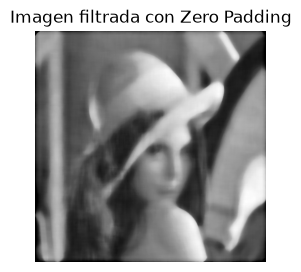

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter as scipy_median

def median_filter(image, size, padding_type='zero'):
    if padding_type == 'zero':
        # Calcula el ancho del borde a rellenar
        pad_width = size // 2
        # Rellena los bordes con ceros (constant_values=0)
        padded_image = np.pad(image, pad_width, mode='constant', constant_values=0)
        # Aplica el filtro de mediana sobre la imagen con padding
        filtered = scipy_median(padded_image, size=size)
        # Recorta la imagen para devolverla a su tamaño original
        return filtered[pad_width:-pad_width, pad_width:-pad_width]
    else:
        # Si no se requiere padding manual, usa el comportamiento por defecto
        return scipy_median(image, size=size)

# Parámetros de tu consulta
zero_padding = 'zero'
imageOut = median_filter(noisy_image, 21, zero_padding)

# Visualización
plt.imshow(imageOut, cmap='gray')
plt.title('Imagen filtrada con Zero Padding')
plt.axis('off')
plt.show()


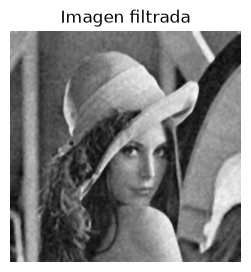

In [20]:
imageOut = median_filter(noisy_image, 7, mirror_padding)
plt.imshow(imageOut, cmap='gray')
plt.title('Imagen filtrada')
plt.axis('off')
plt.show()

El filtro de mediana es particularmente útil en presencia de ruido _sal y pimienta_ que aparece como puntos blancos y negros aleatoriamente ubicados en la imagen.

<!--
def ruido_sal_pimienta(img, noise_prob):
    '''
    Esta función adicionan ruido sal y pimimienta a una imagen con base en una probabilidad de ruido (noise_prob),
    a mayor probabilidad mayor ruido.

    Una forma de implementarlo es generando una matriz aleatoria del tamaño de la imagen y utilizar la probabilidad como un umbral.

    Retorna la imagen con ruido.
    '''
    noise = 100*np.random.random(size=img.shape) # Matriz aleatoria con distribución gaussiana en el rango [0,100)
    sal = (noise > (100-noise_prob)) # Umbralización mayor que para las posiciones donde irán puntos blancos
    pimienta = (noise < noise_prob) # Umbralización menor que para las posiciones donde irán puntos negros
    img[sal] = 255
    img[pimienta] = 0
    return img
-->

In [27]:
def ruido_sal_pimienta(img, noise_prob):
    '''
    Esta función adiciona ruido sal y pimienta a una imagen con base en una probabilidad de ruido (noise_prob),
    a mayor probabilidad mayor ruido.

    Una forma de implementarlo es generando una matriz aleatoria del tamaño de la imagen y utilizar la probabilidad como un umbral.

    Retorna la imagen con ruido.
    '''
    # Creamos una copia para no modificar la imagen original
    noisy_image = np.copy(img)

    # Pasamos la probabilidad de porcentaje (0-100) a decimal (0-1) si es necesario.
    # En tu bloque anterior pasaste '20', por lo que dividimos entre 100 para que sea 0.20
    if noise_prob > 1.0:
        prob = noise_prob / 100.0
    else:
        prob = noise_prob

    # Generamos la matriz aleatoria con una distribución uniforme entre 0 y 1
    random_matrix = np.random.rand(*img.shape[:2])

    # Mitad de la probabilidad para la sal (blanco) y mitad para la pimienta (negro)
    half_prob = prob / 2.0

    # Aplicamos los umbrales
    # Píxeles donde la matriz es menor que half_prob se vuelven Sal (255)
    noisy_image[random_matrix < half_prob] = 255

    # Píxeles donde está entre half_prob y prob se vuelven Pimienta (0)
    noisy_image[(random_matrix >= half_prob) & (random_matrix < prob)] = 0

    return noisy_image


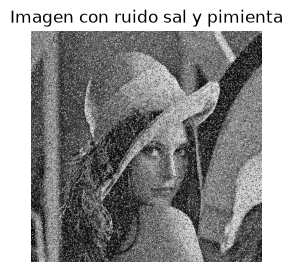

In [26]:
noisy_image = ruido_sal_pimienta(input_image, 20)
plt.imshow(noisy_image, cmap='gray')
plt.title('Imagen con ruido sal y pimienta')
plt.axis('off')
plt.show()

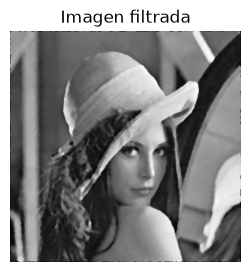

In [28]:
imageOut = median_filter(noisy_image, 7, zero_padding)
plt.imshow(imageOut, cmap='gray')
plt.title('Imagen filtrada')
plt.axis('off')
plt.show()

## Filtros de realce de bordes

Los filtros realce de bordes (_sharpening_) pueden verse como filtros pasaaltas, en contraste con los filtros de suavizado o pasabajas. Desde el punto de vista matemático, los filtros de suavizado corresponden a integrar la señal, y los filtros de realce a derivar la señal. Los dos principales son los filtros de 2da derivada o laplacianos de la forma:

<img src="https://github.com/MoraRubio/dip-uam/blob/main/src/laplacianfilters.png?raw=true" alt="Kernels laplacianos" style="height: 200px; width:700px;"/>

Y los filtros basados en la primera derivada o de gradiente (Operadores Sobel):

<img src="https://github.com/MoraRubio/dip-uam/blob/main/src/sobel.png?raw=true" alt="Kernels laplacianos" style="height: 200px; width:400px;"/>


Dimensiones de la imagen:  (192, 204)
Tipo de dato:  uint8
Nivel máximo de intensidad:  255
Nivel mínimo de intensidad:  0


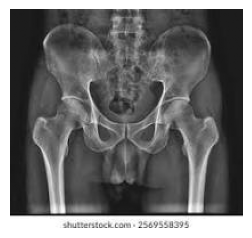

In [34]:
input_image=cv2.imread('radiografia_femur.jpg', cv2.IMREAD_GRAYSCALE)
img_max = np.max(input_image)
img_min = np.min(input_image)
alto, ancho = input_image.shape
print("Dimensiones de la imagen: ", input_image.shape)
print("Tipo de dato: ", input_image.dtype)
print("Nivel máximo de intensidad: ", img_max)
print("Nivel mínimo de intensidad: ", img_min)
plt.imshow(input_image, cmap='gray')
plt.axis('off')
plt.show()

✅ Imagen cargada correctamente.
Dimensiones de la imagen (Alto, Ancho):  (192, 204)
Tipo de dato:  uint8
Nivel máximo de intensidad:  255
Nivel mínimo de intensidad:  0


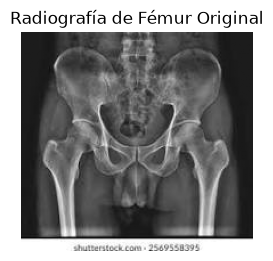

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Define la ruta (puedes cambiarla por la ruta absoluta si sigue fallando)
ruta_imagen = 'radiografia_femur.jpg'

# Verificar si el archivo realmente existe en el disco antes de leerlo
if not os.path.exists(ruta_imagen):
    print(f"❌ Error: El archivo '{ruta_imagen}' no existe en la ruta especificada.")
    print(f"Tu directorio de trabajo actual es: {os.getcwd()}")
else:
    # 2. Intentar cargar la radiografía
    input_image = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

    # Doble verificación por si el archivo existe pero está corrupto
    if input_image is None:
        print("❌ Error: OpenCV no pudo decodificar la imagen. El archivo podría estar corrupto.")
    else:
        # 3. Extraer metadatos si la carga fue exitosa
        img_max = np.max(input_image)
        img_min = np.min(input_image)
        alto, ancho = input_image.shape

        # 4. Imprimir el diagnóstico
        print("✅ Imagen cargada correctamente.")
        print("Dimensiones de la imagen (Alto, Ancho): ", input_image.shape)
        print("Tipo de dato: ", input_image.dtype)
        print("Nivel máximo de intensidad: ", img_max)
        print("Nivel mínimo de intensidad: ", img_min)

        # 5. Visualización
        plt.imshow(input_image, cmap='gray', vmin=0, vmax=255)
        plt.title('Radiografía de Fémur Original')
        plt.axis('off')
        plt.show()


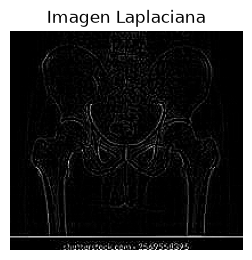

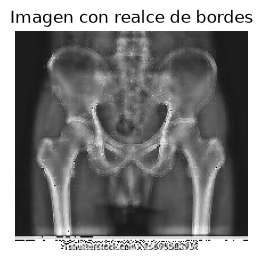

In [36]:
laplacian = np.array([[0, 1, 0],
                      [1,-4, 1],
                      [0, 1, 0]], dtype=np.float32)

image_lap = cv2.filter2D(input_image, -1, laplacian)
plt.imshow(image_lap, cmap='gray')
plt.title('Imagen Laplaciana')
plt.axis('off')
plt.show()

c = 1
imageOut = input_image + c*image_lap
plt.imshow(imageOut, cmap='gray')
plt.title('Imagen con realce de bordes')
plt.axis('off')
plt.show()

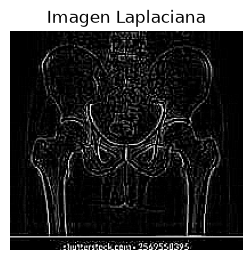

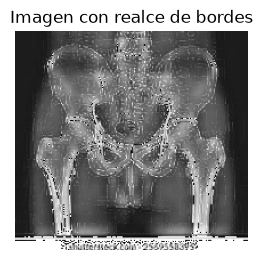

In [37]:
laplacian = np.array([[1, 1, 1],
                      [1,-8, 1],
                      [1, 1, 1]], dtype=np.float32)

image_lap = cv2.filter2D(input_image, -1, laplacian)
plt.imshow(image_lap, cmap='gray')
plt.title('Imagen Laplaciana')
plt.axis('off')
plt.show()

c = 1
imageOut = input_image + c*image_lap
plt.imshow(imageOut, cmap='gray')
plt.title('Imagen con realce de bordes')
plt.axis('off')
plt.show()

**Copyright**

The notebooks are provided as [Open Educational Resource](https://de.wikipedia.org/wiki/Open_Educational_Resources). Feel free to use the notebooks for your own educational purposes. The text is licensed under [Creative Commons Attribution 4.0](https://creativecommons.org/licenses/by/4.0/), the code of the IPython examples under the [MIT license](https://opensource.org/licenses/MIT).